Libraries for Data Collection and Other Functions

In [76]:
import os
import shutil
import json
import copy
from datetime import datetime
import zipfile
import io
import requests
import random

Libraries for Data Processing and Visualization 

In [75]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.pyplot import imshow
from tqdm import tqdm
import time 

Libraries for Deep Learning

In [74]:
import torch
import torchvision.models as models
from torchvision import transforms
import torch.nn as nn
torch.manual_seed(0)
from torchvision.datasets import ImageFolder

Reference for Transfer Learning: 
https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

Functions
    

In [79]:
def imshow_(inp, title=None):
    """
    Displays a tensor image after reversing normalization.
    
    Parameters:
    - inp (Tensor): Image tensor of shape [C, H, W], usually normalized.
    - title (str, optional): Title for the image display.
    """

    # Convert from [C, H, W] to [H, W, C] and to NumPy array
    # 1. Clone to avoid modifying the original tensor
    img_tensor = inp.clone().detach()

    # 2. Reshape mean/std to (C, 1, 1) so PyTorch can broadcast over (C, H, W)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    # 3. Denormalize and clamp
    img_tensor = img_tensor * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)

    # 4. Permute and convert to numpy for matplotlib
    plt.imshow(img_tensor.permute(1, 2, 0).numpy())
    if title is not None:
        plt.title(title)
    plt.show()

In [66]:
def plot_stuff(COST, ACC):
    """
    Plots training cost (loss) and validation accuracy on the same figure using two y-axes.
    
    Parameters:
    COST (list or array): Total training loss per iteration (or epoch)
    ACC (list or array): Validation accuracy per iteration (or epoch)
    """
    
    plt.plot(COST, color='red', label='Loss')
    plt.plot(ACC, color='blue', label='Accuracy')
    plt.xlabel('Iteration')
    plt.legend()
    plt.show()


Input and Load Data in JSON Annotations File

In [4]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ExisQFol3hUHktTjm6a51w/final-project-stop-signs-1-2025-04-25-t-06-47-41-058-z.zip"

response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall("not_stopandstop")  # Extract to a target folder
    print("Download and extraction complete.")
else:
    print("Failed to download file:", response.status_code)

source_dir = "not_stopandstop/final-project-stop-signs-1-2025-04-25-t-06-47-41-058-z"  
annotations_file = os.path.join(source_dir, "_annotations.json")  

with open(annotations_file, "r") as f:
    annotations = json.load(f)

print("Annotations loaded successfully!")

Download and extraction complete.
Annotations loaded successfully!


In [13]:
print(f"number of images {len(annotations['annotations'])}")

number of images 197


In [ ]:
source_dir = "not_stopandstop/final-project-stop-signs-1-2025-04-25-t-06-47-41-058-z"  # folder containing images and annotation file
annotations_file = os.path.join(source_dir, "_annotations.json")  

with open(annotations_file, "r") as f:
    annotations = json.load(f)

In [ ]:
# Inspect the raw annotation structure (filename -> label mapping)
annotations['annotations']

{'4d160925-f898-4364-8396-4992fbd76b71.jpg': [{'label': 'not_stop',
   'id': 'ff23432e-85af-49eb-8612-f014844b2cf3'}],
 '7f8e60d4-e2ef-4145-b258-b128b808bd96.jpg': [{'label': 'not_stop',
   'id': '251c7358-684f-42b6-8e71-b9ba7771381b'}],
 '60e51cce-96d5-4bb1-b748-299d2a9fc644.jpg': [{'label': 'not_stop',
   'id': 'a20293b0-4671-4603-b5c1-348abfd1c468'}],
 'e5b58fd6-68e7-41c6-ad6c-08c7563ac9d3.jpg': [{'label': 'not_stop',
   'id': 'ced781ee-ccd8-41fb-827e-3366821d7e1e'}],
 'c5e3624f-6b5a-4128-8eea-a57f4013c74b.jpg': [{'label': 'not_stop',
   'id': '6eaf6fd8-4959-4e9e-a203-04e7df853708'}],
 'eff7bd5e-0ee8-4b02-bf54-52b4e1eca781.jpg': [{'label': 'not_stop',
   'id': '0d80cfdf-7e86-460a-8a0d-2750a7c28854'}],
 'faba8d13-e92e-4bf9-ae6c-b7fb906572fa.jpg': [{'label': 'not_stop',
   'id': '66a7a892-ad63-41dc-9c34-b17dad1285cc'}],
 'd7ed0cdb-95fc-457d-b537-0b8311778004.jpg': [{'label': 'not_stop',
   'id': 'be0e2860-4504-454b-b09a-72b6ea013fc5'}],
 'f4fd778e-e069-4e14-851a-e6f369f64615.jpg': [{'

In [ ]:
####change the order of the map, so that we can easily shuffle and split data into traning and validation set

label_to_images = {}

for filename, entry in annotations["annotations"].items():
    label = entry[0]["label"]
    if label not in label_to_images:
        label_to_images[label] = []
    label_to_images[label].append(filename)


['cd338387-124f-48f5-a7ca-e84890b09f29.jpg',
 '2d4d3beb-772a-465b-b805-a8c039bdaa3c.jpg',
 '52b61ab9-11c3-42a8-9514-801fb08f18d6.jpg',
 '8a9b335c-02ea-4525-9afb-29a370447369.jpg',
 '7d12fcc5-d9ee-405c-b978-b1ed38c63e18.jpg',
 'e9f3ba87-3c1c-4511-95d2-d8c56405b853.jpg',
 '11449616-b137-404b-81c0-96fdced2b174.jpg',
 '1ff8b054-a709-417f-9e5a-f905776d34c8.jpg',
 'b587335b-0a6c-4a1a-bfc5-5991a7e12cb3.jpg',
 '8ce624f0-1ed8-4a6f-b49f-1b5131461b6f.jpg',
 'ba079768-33a1-446b-9845-dbda143f3dc1.jpg',
 'd688053d-2847-434b-81d0-ef6acbdcb73c.jpg',
 'd7f9c2ab-7245-4271-831d-0d130154e227.jpg',
 '5b8f8bdb-c681-494d-98a2-55c139be2898.jpg',
 '560a8bd1-1c96-4251-be55-063dc8e1cee2.jpg',
 'ad71df5b-c6a8-413d-b8c2-4eba9c5cb607.jpg',
 'f3f7a336-d784-4940-83eb-f2ce61830bc5.jpg',
 'd2d453e1-daca-4498-abd7-1ea5ab241a87.jpg',
 'd93600a3-1bc6-4ad7-9e2a-04b00728d85f.jpg',
 '96d3cf1b-2a6f-44b0-b727-84984ddb7a35.jpg',
 '69522844-5670-44a6-8dfe-559324309dca.jpg',
 'ce6d2be3-fe5f-44c0-b6c6-ffc4f9382bfb.jpg',
 'b958c237

In [ ]:
train_ratio = 0.9
output_dir = "dataset"  

In [ ]:
# Shuffle each class and copy its images into dataset/train/<label> and dataset/val/<label>

for label, image_list in label_to_images.items():
    random.shuffle(image_list)  
    
    train_cutoff = int(len(image_list) * train_ratio)
    
    train_images = image_list[:train_cutoff]
    val_images = image_list[train_cutoff:]

    # Loop over both splits: 'train' and 'val'
    for split, split_images in zip(["train", "val"], [train_images, val_images]):
        
        out_path = os.path.join(output_dir, split, label)
        os.makedirs(out_path, exist_ok=True)  

        
        for img_name in split_images:
            src = os.path.join(source_dir, img_name)  
            dst = os.path.join(out_path, img_name)    
            shutil.copy2(src, dst)  


print("Train/Val split complete.")

Train/Val split complete.


Transform shape and normalize all images for easier computing. 

Normalization parameters for all Image Net Models : https://albumentations.ai/explore/transform/Normalize/

In [25]:
transform = transforms.Compose([
    transforms.Resize( (224,224)), 
    transforms.ToTensor(), 
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],     
        std=[0.229, 0.224, 0.225]       
    )
])

In [26]:
from torchvision.datasets import ImageFolder

# Load datasets from the respective folders
train_dataset = ImageFolder(root="dataset/train", transform=transform)
val_dataset = ImageFolder(root="dataset/val", transform=transform)

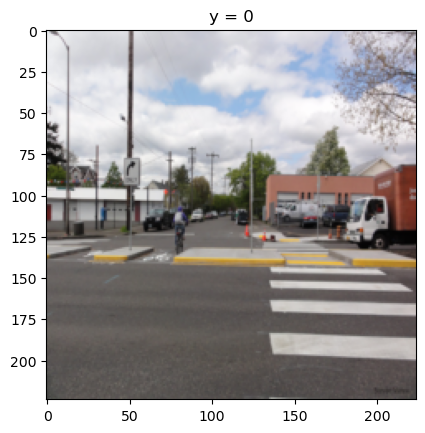

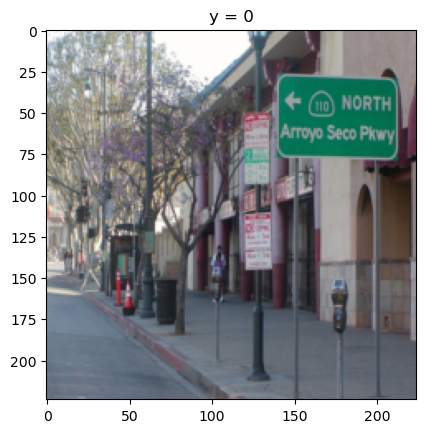

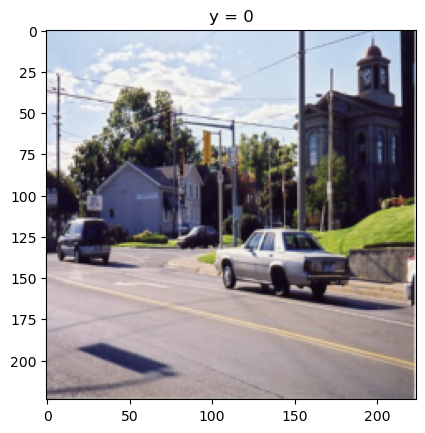

In [80]:
### Plot to verify the image can be accessed through the tensor. Use the pre-defined function to reverse tensor normalization transformation. 

i = 0
for x, y in train_dataset:
    imshow_(x, f"y = {y}")
    i += 1
    if i == 3:
        break

Hyperparameters

In [35]:
n_epochs = 10    # A typical small number like 10
batch_size = 32   # Try 32

In [ ]:
learning_rate = 0.001
momentum = 0.9

In [34]:
lr_scheduler = True          # Set True or False to control usage
base_lr = 0.001              # Minimum learning rate (e.g., 0.001)
max_lr = 0.01    

In [37]:
model = models.resnet18(pretrained=True)

C:\Users\Dhana\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Dhana\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Dhana/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 81.2MB/s]


In [38]:
for param in model.parameters():
    param.requires_grad = False

In [40]:
n_classes = len(train_dataset.classes)
print(n_classes)


2


In [41]:
model.fc = nn.Linear(model.fc.in_features, n_classes)

In [43]:
criterion = nn.CrossEntropyLoss()

Load the Dataset and prepeare optimizeer, learning rate_scheduler

In [45]:
train_loader = torch.utils.data.DataLoader(dataset= train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = torch.utils.data.DataLoader(dataset= val_dataset, batch_size=1)


In [48]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

In [49]:
if lr_scheduler:
    scheduler = torch.optim.lr_scheduler.CyclicLR(
        optimizer,
        base_lr= base_lr,        # Minimum learning rate e.g 0.001
        max_lr= max_lr,         # Maximum learning rate e.g 0.01
        step_size_up=5,
        mode="triangular2"
    )

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
def train_model(model, train_loader, validation_loader, criterion, optimizer, n_epochs, print_=True):
    ###
    ### Trains the model for n_epochs, running a validation pass after each epoch.
    ### For every epoch it loops over the training batches to compute loss, backpropagate,
    ### and update weights, then evaluates accuracy on the validation set with gradients disabled.
    ### The weights that produce the highest validation accuracy are saved and reloaded at the end,
    ### so the returned model is the best-performing one rather than the last.
    ### Returns: accuracy_list (validation accuracy per epoch), loss_list (avg training loss per epoch), model (best weights loaded).
    ###
    loss_list = []        
    accuracy_list = []    
    correct = 0           

    n_test = len(val_dataset)                         
    accuracy_best = 0                                  
    best_model_wts = copy.deepcopy(model.state_dict()) 

    print("The first epoch should take several minutes")

    # Loop over the dataset n_epochs times
    for epoch in tqdm(range(n_epochs)):
        loss_sublist = []   

        # ---- Training phase ----
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)   
            model.train()                       

            z = model(x)                        
            loss = criterion(z, y)              
            loss_sublist.append(loss.item())    

            loss.backward()         
            optimizer.step()       
            optimizer.zero_grad()   

        print(f"Epoch {epoch + 1} done")

        scheduler.step()            

        loss_list.append(np.mean(loss_sublist))   

        # ---- Validation phase ----
        correct = 0
        model.eval()                
        with torch.no_grad():       
            for x_test, y_test in validation_loader:
                x_test, y_test = x_test.to(device), y_test.to(device)
                z = model(x_test)                     
                _, yhat = torch.max(z.data, 1)        
                correct += (yhat == y_test).sum().item()  

        accuracy = correct / n_test        
        accuracy_list.append(accuracy)     

        # ---- Keep the best-performing weights ----
        if accuracy > accuracy_best:
            accuracy_best = accuracy                            
            best_model_wts = copy.deepcopy(model.state_dict())  
        if print_:
            print("Learning rate:", optimizer.param_groups[0]['lr'])
            print(f"Validation loss (epoch {epoch + 1}): {np.mean(loss_sublist):.4f}")
            print(f"Validation accuracy (epoch {epoch + 1}): {accuracy:.4f}")

    model.load_state_dict(best_model_wts)   # Restore the best weights before returning
    return accuracy_list, loss_list, model

In [81]:
start_datetime = datetime.now()
start_time = time.time()


accuracy_list, loss_list, model = train_model(
    model, train_loader, validation_loader, criterion, optimizer, n_epochs=n_epochs
)

end_datetime = datetime.now()
elapsed_time = time.time() - start_time

# Print results
print("Training completed.")
print(f"Start Time     : {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"End Time       : {end_datetime.strftime('%Y-%m-%d   %H:%M:%S')}")
print(f"Elapsed Time   : {elapsed_time:.2f} seconds")

The first epoch should take several minutes


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 done


 10%|█         | 1/10 [00:08<01:14,  8.27s/it]

Learning rate: 0.0014500000000000006
Validation loss (epoch 1): 0.1556
Validation accuracy (epoch 1): 0.9500
Epoch 2 done


...

Learning rate: 0.001900000000000001
Validation loss (epoch 8): 0.1711
Validation accuracy (epoch 8): 0.9500
Epoch 9 done


 90%|█████████ | 9/10 [01:19<00:08,  8.85s/it]

Learning rate: 0.0014500000000000006
Validation loss (epoch 9): 0.1662
Validation accuracy (epoch 9): 0.9500
Epoch 10 done


100%|██████████| 10/10 [01:27<00:00,  8.80s/it]

Learning rate: 0.001
Validation loss (epoch 10): 0.1738
Validation accuracy (epoch 10): 0.9500
Training completed.
Start Time     : 2026-07-16 23:32:29
End Time       : 2026-07-16   23:33:57
Elapsed Time   : 87.98 seconds


In [ ]:
#save the model 
torch.save(model.state_dict(), 'model.pt')

Load the Model for Evaluvation`

In [68]:
class_names = ['not_stop', 'stop']

model = models.resnet18(pretrained=False)

model.fc = torch.nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load("model.pt", map_location=torch.device('cpu')))

model.eval()

C:\Users\Dhana\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Dhana\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Transform for the Testing Image

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

Test a sample image

In [72]:
image_path = "not-stop-1.jpeg"
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0)

The image was classified as: not_stop


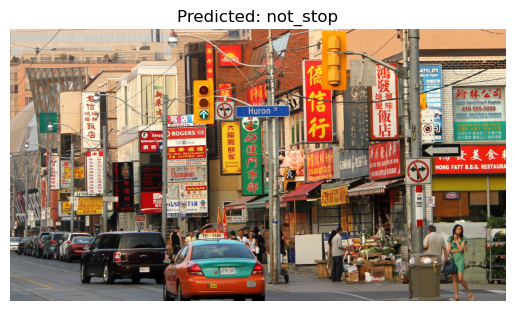

In [73]:
with torch.no_grad():
    outputs = model(input_tensor)
    predicted_class = torch.argmax(outputs, dim=1).item()

print(f"The image was classified as: {class_names[predicted_class]}")

plt.imshow(image)
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis("off")
plt.show()